<a href="https://colab.research.google.com/github/niranjananaveen6/MGNM-801-CA1/blob/main/ca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installing Yahoo Finance

!pip install yfinance --quiet

import yfinance as yf
import pandas as pd

# Downloading 2 years of daily data for Cloudflare

df=yf.download('NET',start='2023-09-01',end='2025-09-10')

print(df.shape)
df.head()


/tmp/ipykernel_4004/501262286.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download('NET',start='2023-09-01',end='2025-09-10')
[*********************100%***********************]  1 of 1 completed

(506, 5)


Price,Close,High,Low,Open,Volume
Ticker,NET,NET,NET,NET,NET
Date,,,,,
2023-09-01,63.990002,66.920998,63.590000,65.860001,2708200
2023-09-05,65.309998,65.379997,63.029999,63.400002,2686000
2023-09-06,63.990002,65.394997,63.040001,64.559998,2795900
2023-09-07,63.529999,64.010002,60.745998,60.770000,2687300
2023-09-08,62.680000,64.110001,62.306000,63.400002,1907800


In [ ]:
# Missing values and Duplicates

df=df.drop_duplicates()
df=df.dropna()

df.columns = df.columns.get_level_values(0)
df = df.reset_index()
print(df.columns)
df.head()


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Date,Close,High,Low,Open,Volume
0,2023-09-01,63.990002,66.920998,63.590000,65.860001,2708200
1,2023-09-05,65.309998,65.379997,63.029999,63.400002,2686000
2,2023-09-06,63.990002,65.394997,63.040001,64.559998,2795900
3,2023-09-07,63.529999,64.010002,60.745998,60.770000,2687300
4,2023-09-08,62.680000,64.110001,62.306000,63.400002,1907800


In [ ]:
# Examining the data

print("Data types:\n", df.dtypes)
print("\nMissing values:\n",df.isnull().sum())
print("\nDuplicate rows:",df.duplicated().sum())
print("\nSummary stats:\n",df.describe())


Data types:
 Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

Missing values:
 Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Duplicate rows: 0

Summary stats:
 Price                           Date       Close        High         Low  \
count                            506  506.000000  506.000000  506.000000   
mean   2024-09-04 07:46:43.162055424  107.423814  109.295972  105.188652   
min              2023-09-01 00:00:00   54.950001   56.715000   53.881001   
25%              2024-03-05 06:00:00   78.412500   79.710001   77.092497   
50%              2024-09-04 12:00:00   91.764999   93.825001   90.075001   
75%              2025-03-09 06:00:00  121.000000  122.911253  118.031498   
max              2025-09-09 00:00:00  218.559998  220.990005  216.229996   
std                              NaN   42.012266   42.597056   4

In [ ]:
#Dropping Duplicates

df = df.drop_duplicates()
df = df.dropna()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(df.dtypes)
print(df.shape)

Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object
(506, 6)


In [ ]:
df['Daily_Return'] = df['Close'].pct_change() * 100
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()
df['Price_Range'] = df['High'] - df['Low']
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna().reset_index(drop=True)
print(df.shape)
df.head()

(477, 11)


Price,Date,Close,High,Low,Open,Volume,Daily_Return,MA_7,MA_30,Price_Range,Target
0,2023-10-13,61.160000,63.500000,60.645000,62.400002,2538100,-2.331522,62.719999,61.970000,2.855000,1
1,2023-10-16,63.509998,64.529999,61.480000,61.900002,3370300,3.842378,63.482856,61.954000,3.049999,1
2,2023-10-17,64.629997,65.849998,62.000000,62.000000,3657900,1.763500,63.779999,61.931333,3.849998,0
3,2023-10-18,62.430000,64.650002,62.240002,64.199997,2288400,-3.403987,63.599999,61.879333,2.410000,1
4,2023-10-19,62.790001,63.959999,61.990002,62.750000,2291300,0.576647,63.204285,61.854666,1.969997,0


In [ ]:
# Descriptive Statistics

print(df[['Close', 'Volume', 'Daily_Return', 'Price_Range']].describe())

mean_close = df['Close'].mean()
std_close = df['Close'].std()
min_close = df['Close'].min()
max_close = df['Close'].max()

print("Average Closing Price:", mean_close)
print("Standard Deviation (Volatility):", std_close)
print("Minimum Closing Price:", min_close)
print("Maximum Closing Price:", max_close)


Price       Close        Volume  Daily_Return  Price_Range
count  477.000000  4.770000e+02    477.000000   477.000000
mean   110.185556  3.312530e+06      0.313080     4.202111
std     41.697968  2.375539e+06      3.211141     2.750765
min     54.950001  5.265000e+05    -16.376306     0.849998
25%     79.820000  2.171600e+06     -1.389785     2.410000
50%     94.830002  2.771000e+06      0.249829     3.415001
75%    123.930000  3.780800e+06      1.791871     5.099991
max    218.559998  3.319190e+07     19.499503    19.050003
Average Closing Price: 110.18555574397121
Standard Deviation (Volatility): 41.69796807821535
Minimum Closing Price: 54.95000076293945
Maximum Closing Price: 218.55999755859375


In [ ]:
#Overall Trend
start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
change = end_price - start_price
percent_change = (change / start_price) * 100

print("Start Price:", start_price)
print("End Price:", end_price)
print("Overall Change (%):", percent_change)


Start Price: 61.15999984741211
End Price: 218.55999755859375
Overall Change (%): 257.35774706324133


In [ ]:
# Average Daily Return
avg_return = df['Daily_Return'].mean()
print("Average Daily Return (%):", avg_return)

Average Daily Return (%): 0.31307955368103885


In [ ]:
# Relationship between Volume and Daily Return
correlation = df['Volume'].corr(df['Daily_Return'])
print("Correlation between Volume and Daily Return:", correlation)

Correlation between Volume and Daily Return: 0.2720610627336592


In [ ]:
# Up Days vs Down Days
up_days = df[df['Target'] == 1].shape[0]
down_days = df[df['Target'] == 0].shape[0]

print("Number of Up Days:", up_days)
print("Number of Down Days:", down_days)

Number of Up Days: 260
Number of Down Days: 217


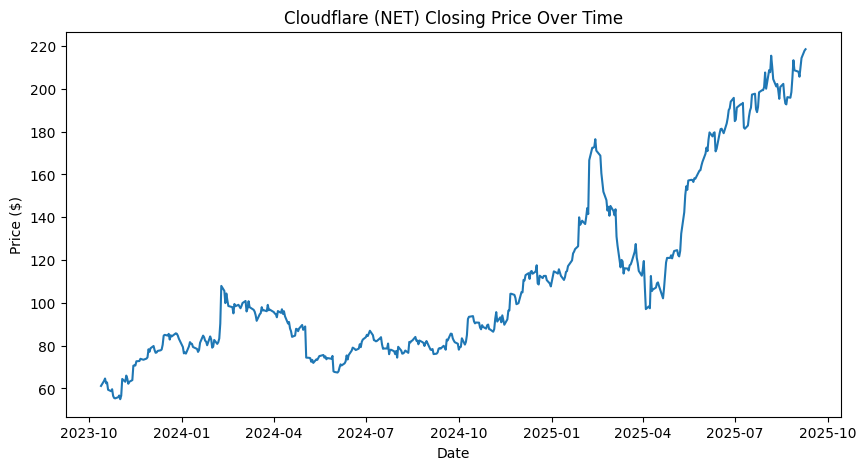

In [ ]:
#Line Chart: Closing price over time
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title('Cloudflare (NET) Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.show()


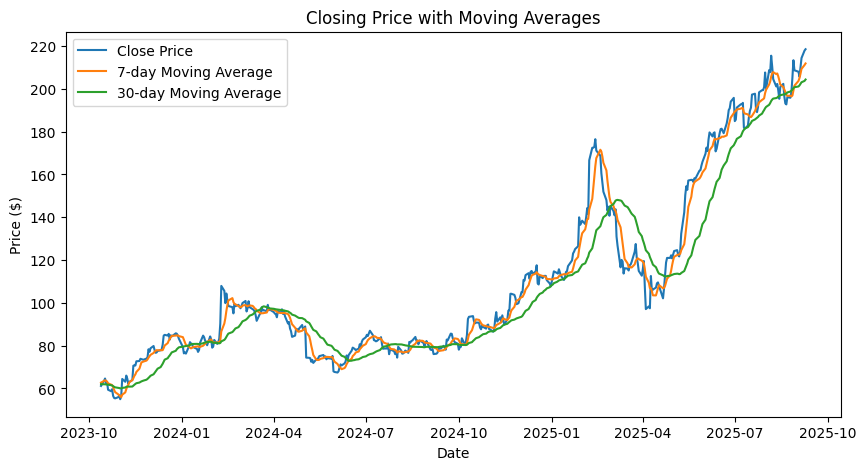

In [ ]:
#Closing Price with Moving Averages
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA_7'], label='7-day Moving Average')
plt.plot(df['Date'], df['MA_30'], label='30-day Moving Average')
plt.title('Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

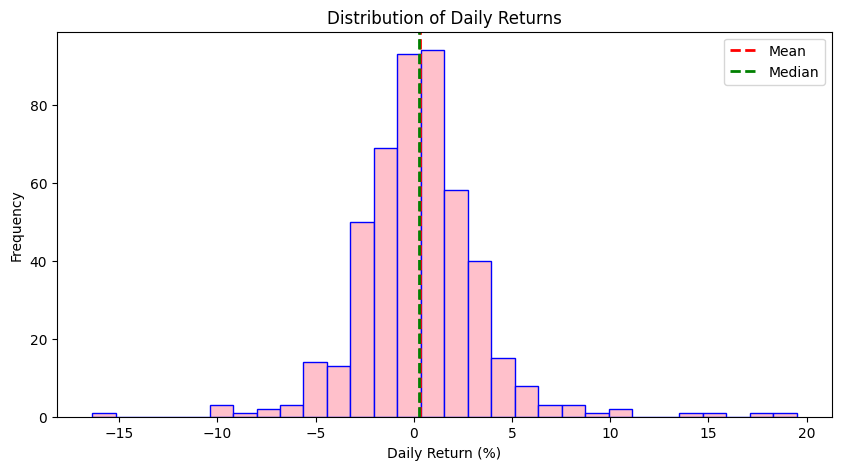

In [ ]:
#Histogram of daily returns
plt.figure(figsize=(10,5))
plt.hist(df['Daily_Return'], bins=30,color='pink', edgecolor='blue')
plt.axvline(df['Daily_Return'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df['Daily_Return'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
plt.legend()
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

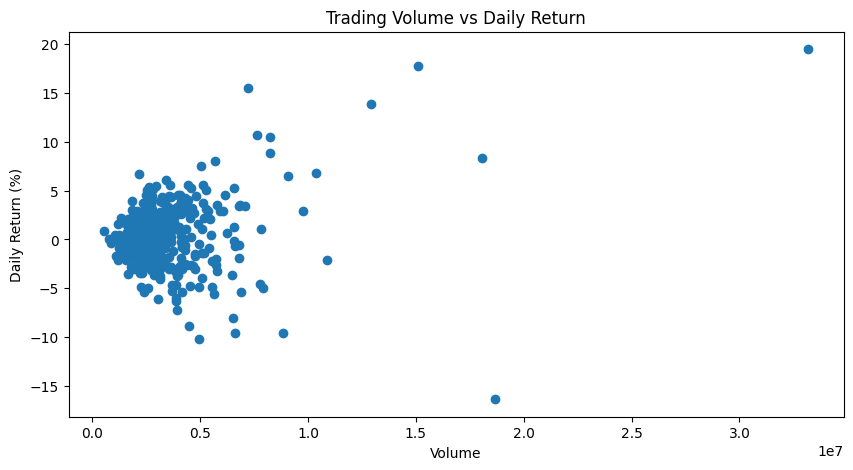

In [ ]:
#Scatter plot: Volume vs daily return
plt.figure(figsize=(10,5))
plt.scatter(df['Volume'], df['Daily_Return'])
plt.title('Trading Volume vs Daily Return')
plt.xlabel('Volume')
plt.ylabel('Daily Return (%)')
plt.show()

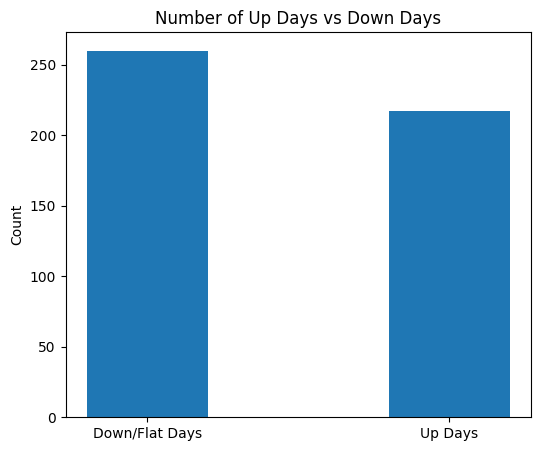

In [ ]:
#Bar chart: Up days vs down days
target_counts = df['Target'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(['Down/Flat Days', 'Up Days'], target_counts,width=0.4)
plt.title('Number of Up Days vs Down Days')
plt.ylabel('Count')
plt.show()

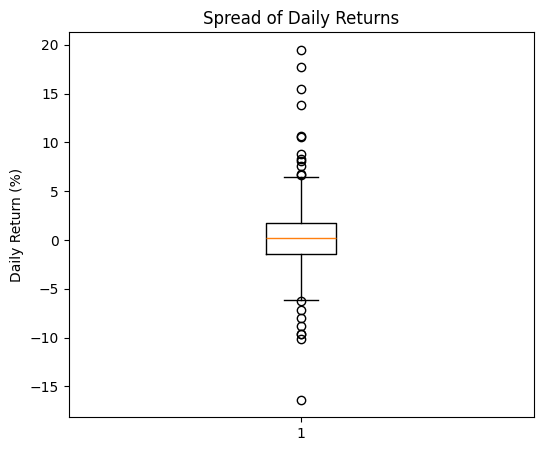

In [ ]:
# Box plot of daily returns
plt.figure(figsize=(6,5))
plt.boxplot(df['Daily_Return'])
plt.title('Spread of Daily Returns')
plt.ylabel('Daily Return (%)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Select independent and dependent variables
X = df[['Daily_Return', 'Volume', 'MA_7', 'MA_30', 'Price_Range']]
y = df['Target']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (381, 5)
Testing data size: (96, 5)


In [ ]:
# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model trained successfully!
Model Accuracy: 0.5520833333333334

Confusion Matrix:
[[ 6 31]
 [12 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.16      0.22        37
           1       0.60      0.80      0.69        59

    accuracy                           0.55        96
   macro avg       0.47      0.48      0.45        96
weighted avg       0.50      0.55      0.51        96



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.5520833333333334

Confusion Matrix:
[[ 6 31]
 [12 47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.16      0.22        37
           1       0.60      0.80      0.69        59

    accuracy                           0.55        96
   macro avg       0.47      0.48      0.45        96
weighted avg       0.50      0.55      0.51        96



In [ ]:
# Check which predictors mattered most to the model
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(importance)

        Feature   Coefficient
0  Daily_Return -7.444991e-03
1        Volume -2.271697e-08
2          MA_7  1.339811e-03
3         MA_30  3.856025e-03
4   Price_Range -8.112523e-02
